<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/SIA_code_workup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Aishwarya thesis clean dataset 27725.xlsx')

In [3]:
df.columns

Index(['name', 'age', 'gender', 'preop kh', 'preop kv', 'preop axis',
       'postop kh', 'postop kv', 'postop axis', '1wk kh', '1wk kv',
       '1wk axis'],
      dtype='object')

In [35]:
df.head()

,name,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,...,preoptheta,postoptheta,X_pre,Y_pre,X_post,Y_post,X_sia,Y_sia,SIA_magnitude,SIA_axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,...,1.570796,0.174533,6.123234e-17,1.000000,2.954423,0.520945,2.954423,-0.479055,2.993010,175.394867
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,...,0.785398,1.221730,3.535534e-01,0.353553,2.223131,6.108002,1.869578,5.754449,6.050537,36.000703
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,...,0.087266,0.610865,3.486681e+00,0.305045,2.867032,2.007518,-0.619649,1.702472,1.811733,55.000000
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,...,2.879793,2.617994,-1.931852e+00,0.517638,-3.897114,2.250000,-1.965263,1.732362,2.619797,69.302052
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,...,1.483530,0.698132,8.715574e-02,0.996195,1.532089,1.285575,1.444933,0.289381,1.473626,5.662475


In [34]:
df['preopcyl'] = df['preop kv']-df['preop kh']
df['postopcyl'] = df['postop kv']-df['postop kh']
df['preopaxis'] = df['preop axis']
df['postopaxis'] = df['postop kh']
df['preoptheta'] = np.deg2rad(df['preop axis'])
df['postoptheta'] = np.deg2rad(df['postop axis'])
df['X_pre'] = df['preopcyl'] * np.cos(df['preoptheta']) * 2
df['Y_pre'] = df['preopcyl'] * np.sin(df['preoptheta']) * 2
df['X_post'] = df['postopcyl'] * np.cos(df['postoptheta']) * 2
df['Y_post'] = df['postopcyl'] * np.sin(df['postoptheta']) * 2
df['X_sia'] = df['X_post']-df['X_pre']
df['Y_sia'] = df['Y_post']-df['Y_pre']
df['SIA_magnitude'] = np.sqrt(df['X_sia']**2 + df['Y_sia']**2)
df['SIA_axis'] = np.rad2deg(np.arctan2(df['Y_sia'], df['X_sia'])) / 2 % 180



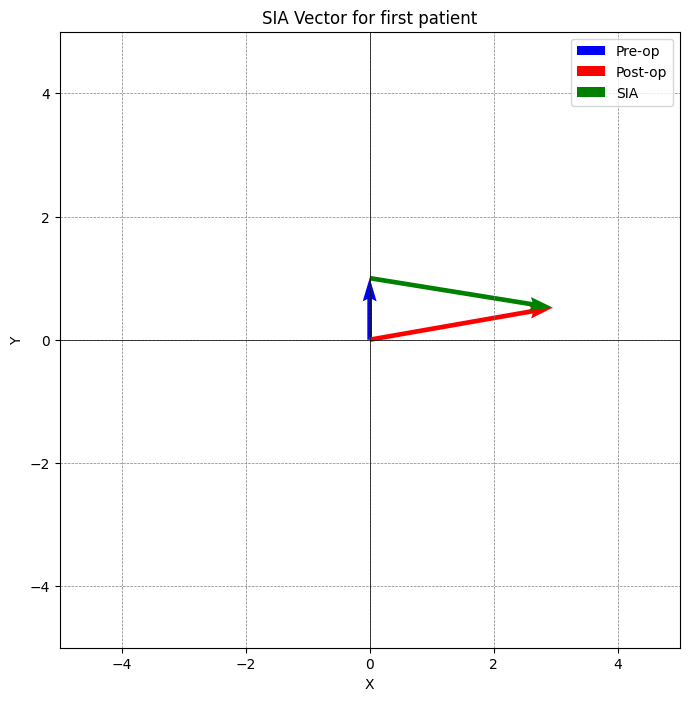

In [40]:
import matplotlib.pyplot as plt

# Extract data for index 0
preop_x = df.loc[0, 'X_pre']
preop_y = df.loc[0, 'Y_pre']
postop_x = df.loc[0, 'X_post']
postop_y = df.loc[0, 'Y_post']
sia_x = df.loc[0, 'X_sia']
sia_y = df.loc[0, 'Y_sia']

# Create the plot
plt.figure(figsize=(8, 8))
plt.quiver(0, 0, preop_x, preop_y, angles='xy', scale_units='xy', scale=1, color='b', label='Pre-op')
plt.quiver(0, 0, postop_x, postop_y, angles='xy', scale_units='xy', scale=1, color='r', label='Post-op')
plt.quiver(preop_x, preop_y, sia_x, sia_y, angles='xy', scale_units='xy', scale=1, color='g', label='SIA')

# Set plot limits and labels
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title('SIA Vector for first patient')

# Show the plot
plt.show()